Input Data Setup (from 2PT simulation)

/Users/jaehyeok/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jaehyeok/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


3.824221471701369e-25
l_0[0] = 7.188800000000059, t_0[0] = 0.006137542032730792


/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_17478/3249055813.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('rainbow')


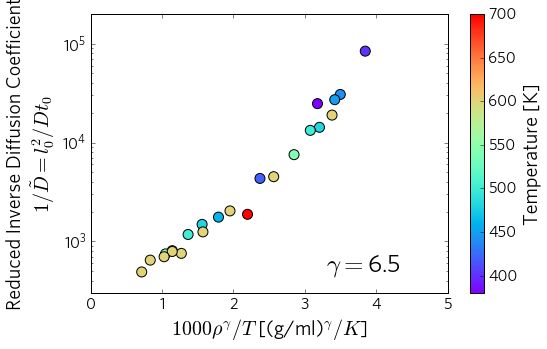

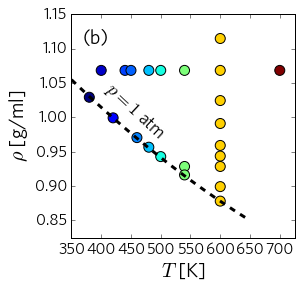

In [1]:
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import constants
from scipy.interpolate import interp1d

# Data setup
plt.style.use('classic')

df = pd.read_csv('ortho_terphenyl.csv')

#u = constants.physical_constants['atomic mass constant'][0]
N_A = constants.Avogadro
molecular_mass = 230.3e-3/N_A
print(molecular_mass)
l_0 = df.Number_Density**(-1/3)  # In Angstrom
t_0 = (molecular_mass/constants.Boltzmann/df.Temperature)**0.5*(l_0*1e-10)*1e9  # in nanoseconds
print(f'{l_0[0] = }, {t_0[0] = }')
df['Reduced_Diffusion_Coefficient'] = df.Diffusion_Coefficient*t_0/l_0**2
cmap = plt.cm.get_cmap('rainbow')

plt.figure(figsize=(8, 5))
plt.rcParams.update({
    #'font.family': 'DejaVu Sans',   # Default font
    'font.family': 'Whitney Book', # Actual font used in the paper (needs to install font first)
})
gamma = 6.5
Gamma = 1000*df.Density**gamma/df.Temperature
sc = plt.scatter(Gamma, 1/df.Reduced_Diffusion_Coefficient, c=df.Temperature, s=100, cmap=cmap)
#plt.plot([0, 5], np.array([2e2, 5e4])*1.1, 'k:', lw=3)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.xlabel(r'$1000\rho^\gamma/T$ [(g/ml)$^\gamma/K$]', fontsize=20)
plt.xlim(0, 5)
plt.ylim(3e2, 2e5)
plt.ylabel(r'Reduced Inverse Diffusion Coefficient' '\n' r'$1/\tilde D=l_0^2/Dt_0$',fontsize=20)
cbar = plt.colorbar(sc)
cbar.set_label('Temperature [K]', fontsize=20)
cbar.ax.tick_params(labelsize=16)

plt.yscale('log')
plt.text(3.3, 5e2, r'$\gamma=$' f'{gamma:0.1f}', fontsize=25)
plt.savefig('density_scaling_otp.pdf', dpi=600, bbox_inches='tight')
plt.savefig('density_scaling_otp.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure with investigated state points
plt.figure(figsize=(4, 4))
plt.rcParams.update({
    #'font.family': 'DejaVu Sans',   # Default font
    'font.family': 'Whitney Book', # Actual font used in the paper (needs to install font first)
})
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.scatter(df.Temperature, df.Density, c=df.Temperature, s=100)
spline_points = ((350, 450, 650), (1.055, 0.977, 0.85))
f = interp1d(*spline_points, kind='quadratic')
x_vals = np.linspace(min(spline_points[0]), max(spline_points[0]), 100)
plt.plot(x_vals, f(x_vals), 'k--', lw=3)
plt.text(400, 0.97, r'$p=1$ atm', fontsize=18, rotation=-43)
plt.text(0.05, 0.87, '(b)', transform=plt.gca().transAxes, fontsize=20)
plt.xlim(350, 725)
plt.ylim(0.825, 1.15)
plt.xlabel(r'$T$ [K]', fontsize=20)
plt.ylabel(r'$\rho$ [g/ml]', fontsize=20)
plt.savefig('density_temperature_otp.pdf', dpi=600, bbox_inches='tight')
plt.savefig('density_temperature_otp.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_17478/3106709609.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('rainbow')
/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_17478/3106709609.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(Gamma_fit, y_fit, 'k--', color='#696969', lw=3, label='_nolegend_')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


3.824221471701369e-25
l_0[0] = 7.188800000000059, t_0[0] = 0.006137542032730792
Fitted parameters: a = 1.0835402581141804, b = 4.868869516679086


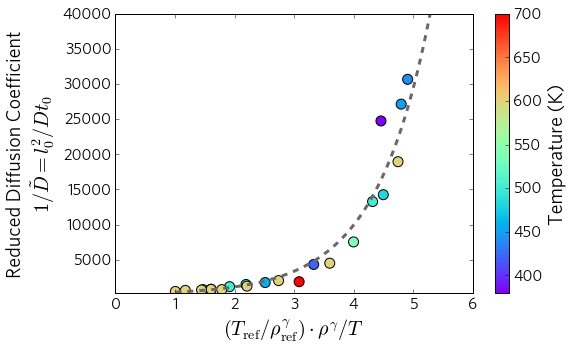

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants
from matplotlib.ticker import FuncFormatter


# Read the data
df = pd.read_csv('ortho_terphenyl.csv')

# Physical constants and parameters
N_A = constants.Avogadro
molecular_mass = 230.3e-3 / N_A
print(molecular_mass)
l_0 = df.Number_Density ** (-1 / 3)  # In Angstrom
t_0 = (molecular_mass / constants.Boltzmann / df.Temperature) ** 0.5 * (l_0 * 1e-10) * 1e9  # in nanoseconds
print(f'{l_0[0] = }, {t_0[0] = }')
df['Reduced_Diffusion_Coefficient'] = df.Diffusion_Coefficient * t_0 / l_0 ** 2
cmap = plt.cm.get_cmap('rainbow')

plt.figure(figsize=(8, 5))
plt.rcParams.update({
    'font.family': 'Whitney Book',  # Actual font used in the paper (needs to install font first)
})
     
gamma = 6.5
Gamma = 1403.886065 * df.Density ** gamma / df.Temperature

# Log-transform the y data
log_y = np.log(1 / df.Reduced_Diffusion_Coefficient)

# Fit the linear model to log(y) = a*x + b
coeffs = np.polyfit(Gamma, log_y, 1)
a, b = coeffs
print(f'Fitted parameters: a = {a}, b = {b}')

# Generate the fitted line
Gamma_fit = np.linspace(min(Gamma), max(Gamma), 500)
log_y_fit = a * Gamma_fit + b
y_fit = np.exp(log_y_fit)

# Plot the fitted line first as a dotted line
plt.plot(Gamma_fit, y_fit, 'k--', color='#696969', lw=3, label='_nolegend_')

# Scatter plot the original data
sc = plt.scatter(Gamma, 1 / df.Reduced_Diffusion_Coefficient, c=df.Temperature, s=100, cmap=cmap)

# Format y-axis as scientific notation
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(r'$(T_\mathrm{ref}/\rho_\mathrm{ref}^\gamma)\cdot\rho^\gamma/T$', fontsize=20)
plt.xlim(0, 6)
plt.ylim(3e2, 4e4)
plt.ylabel(r'Reduced Diffusion Coefficient' '\n' r'$1/\tilde D=l_0^2/Dt_0$', fontsize=20)
cbar = plt.colorbar(sc)
cbar.set_label('Temperature (K)', fontsize=20)
cbar.ax.tick_params(labelsize=16)

plt.yscale('linear')
plt.legend(frameon=False)
plt.savefig('density_scaling_otp_linear.pdf', dpi=600, bbox_inches='tight')
plt.savefig('density_scaling_otp_linear.png', dpi=300, bbox_inches='tight')
plt.show()


Figure Setup

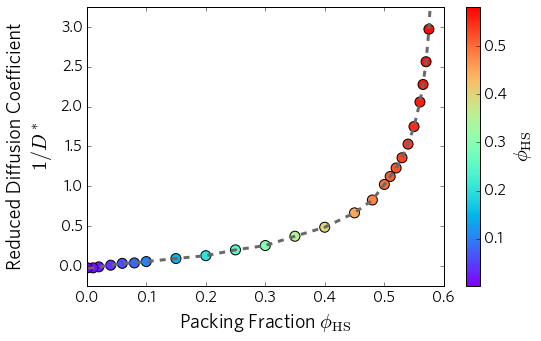

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants
from matplotlib.ticker import FuncFormatter

# Read the data from pre.out
pre_df = np.loadtxt('../../pre.out')
x = pre_df[:, 0]
y = pre_df[:, 1]
color = pre_df[:, 0]

plt.figure(figsize=(8, 5))
plt.rcParams.update({
    'font.family': 'Whitney Book',  # Actual font used in the paper (needs to install font first)
})

# Plot the data
plt.plot(x, y, linestyle='--', lw=3, color='#696969', label='_nolegend_')

sc = plt.scatter(x, y, c=color, s=100, cmap='rainbow')

# Custom y-ticks with specific labels

plt.yticks([1, 10, 100, 1000, 10000], 
           [r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'])

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Packing Fraction $\phi_{\mathrm{HS}}$', fontsize=20)  # Update with the correct label
plt.ylim(-0.25, 3.25)
plt.xlim(0, 0.6)
plt.ylabel(r'Reduced Diffusion Coefficient' '\n' r'$1/D^\ast$', fontsize=20)
cbar = plt.colorbar(sc)
cbar.set_label('$\phi_\mathrm{HS}$', fontsize=20)  # Update with the correct label
cbar.ax.tick_params(labelsize=16)

# Plot the fitted line as a dotted line with RGB color #696969

plt.yscale('linear')
plt.savefig('scatter_plot_pre_out.pdf', dpi=600, bbox_inches='tight')
plt.savefig('scatter_plot_pre_out.png', dpi=300, bbox_inches='tight')
plt.show()


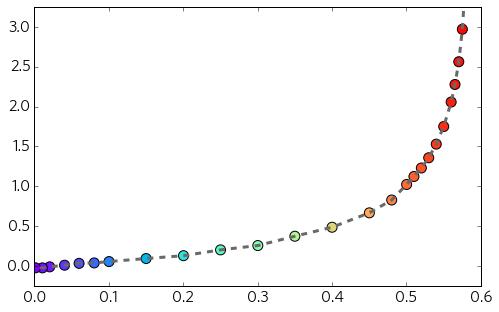

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants
from matplotlib.ticker import FuncFormatter

# Read the data from pre.out
pre_df = np.loadtxt('../../pre.out')
x = pre_df[:, 0]
y = pre_df[:, 1]
color = pre_df[:, 0]

plt.figure(figsize=(8, 5))
plt.rcParams.update({
    'font.family': 'Whitney Book',  # Actual font used in the paper (needs to install font first)
})

# Plot the data
plt.plot(x, y, linestyle='--', lw=3, color='#696969', label='_nolegend_')

sc = plt.scatter(x, y, c=color, s=100, cmap='rainbow')

# Custom y-ticks with specific labels

plt.yticks([1, 10, 100, 1000, 10000], 
           [r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'])

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(-0.25, 3.25)
plt.xlim(0, 0.6)


# Plot the fitted line as a dotted line with RGB color #696969

plt.yscale('linear')
plt.savefig('scatter_plot_pre_out.pdf', dpi=600, bbox_inches='tight')
plt.savefig('scatter_plot_pre_out.png', dpi=300, bbox_inches='tight')
plt.show()


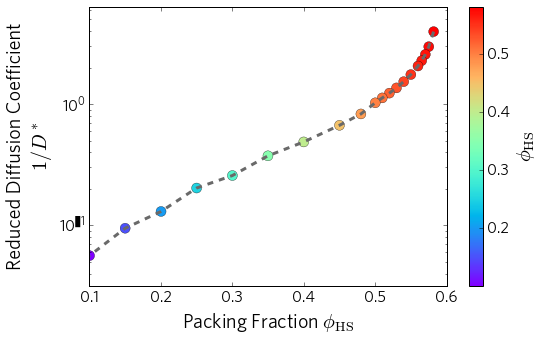

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext

# --------------------------------------------------------------------------
# Read the data
# --------------------------------------------------------------------------
pre_df = np.loadtxt('../../pre.out')
x = pre_df[:, 0]
y = pre_df[:, 1]
color = pre_df[:, 0]

# Use only data where φ_HS > 0.1
mask = x > 0.1
x = x[mask]
y = y[mask]
color = color[mask]

# --------------------------------------------------------------------------
# Plot setup
# --------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.rcParams.update({
    'font.family': 'Whitney Book',  # Must be installed for correct font
})

# Dashed curve directly connecting the data
plt.plot(x, y, linestyle='--', lw=3, color='#696969', label='_nolegend_')

# Scatter points
sc = plt.scatter(x, y, c=color, s=100, cmap='rainbow', edgecolor='k', lw=0.3)

# --------------------------------------------------------------------------
# Axis and style formatting
# --------------------------------------------------------------------------
plt.xlim(0.1, 0.6)
plt.ylim(10**-1.5, 10**0.8)
plt.yscale('log')

plt.xlabel(r'Packing Fraction $\phi_{\mathrm{HS}}$', fontsize=20)
plt.ylabel(r'Reduced Diffusion Coefficient' '\n' r'$1/D^\ast$', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().yaxis.set_major_formatter(LogFormatterMathtext())

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label(r'$\phi_{\mathrm{HS}}$', fontsize=20)
cbar.ax.tick_params(labelsize=16)

# --------------------------------------------------------------------------
# Save and show
# --------------------------------------------------------------------------
plt.savefig('scatter_plot_pre_out_log10.pdf', dpi=600, bbox_inches='tight')
plt.savefig('scatter_plot_pre_out_log10.png', dpi=300, bbox_inches='tight')
plt.show()
